In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Conjunto de dados TechTaste
df_techtaste = pd.DataFrame({'avaliacoes': [38, 44, 33, 42, 47, 33, 36, 39, 42, 36, 39, 34, 42, 42, 36, 43, 31, 35, 36, 41, 42, 30, 25, 38, 47, 36, 32, 45, 44, 45, 37, 48, 37, 36, 44, 49, 31, 45, 45, 40, 36, 50, 38, 34, 36, 42, 46, 49, 36, 34, 38, 31, 53, 40, 57, 40, 36, 42, 26, 50, 32, 43, 35, 37, 42, 30, 36, 43, 40, 43, 44, 52, 37, 51, 35, 47, 40, 50, 37, 49]})

In [ ]:
media = df_techtaste['avaliacoes'].mean()
media

np.float64(40.025)

Calcule o desvio padrão amostral das avaliações.

In [ ]:
DS = df_techtaste['avaliacoes'].std(ddof=1)
print(DS)

6.421827887581661


Calcule o erro padrão amostral da média para as avaliações dos clientes.

In [ ]:
n = len(df_techtaste)

EP = DS/np.sqrt(n)
print(EP)

0.7179821848218235


Utilizando um gráfico de histograma, analise visualmente a distribuição das avaliações dos clientes.

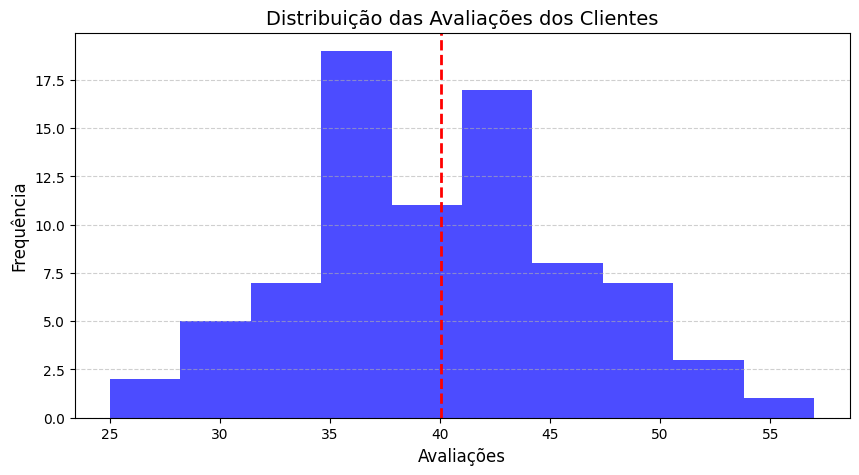

In [ ]:
plt.subplots(figsize=(10,5))

plt.hist(df_techtaste, bins=10, alpha=0.7, color='blue')
plt.title('Distribuição das Avaliações dos Clientes', fontsize=14)
plt.xlabel('Avaliações', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.axvline(media, color='red', linestyle='dashed', linewidth=2, label='Média')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

Com um nível de confiança de 90%, calcule o intervalo de confiança para a média das avaliações.

In [ ]:
intervalo_confinaca_90 = stats.norm.interval(0.90, loc=media, scale=EP)
intervalo_confinaca_90

(np.float64(38.84402439920928), np.float64(41.205975600790715))

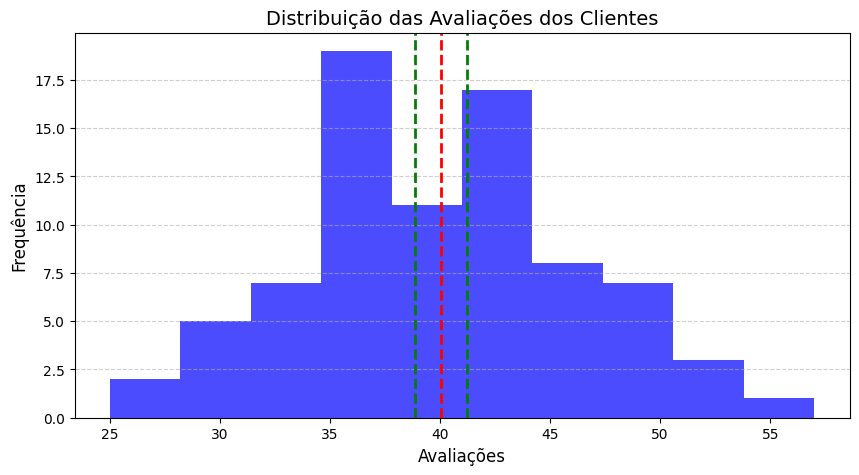

In [ ]:
plt.subplots(figsize=(10,5))

plt.hist(df_techtaste, bins=10, alpha=0.7, color='blue')
plt.title('Distribuição das Avaliações dos Clientes', fontsize=14)
plt.xlabel('Avaliações', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.axvline(media, color='red', linestyle='dashed', linewidth=2, label='Média')
plt.axvline(intervalo_confinaca_90[0], color='green', linestyle='dashed', linewidth=2)
plt.axvline(intervalo_confinaca_90[1], color='green', linestyle='dashed', linewidth=2)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

A largura do intervalo de confiança seria afetada se o nível de confiança fosse aumentado para 95%?

In [ ]:
intervalo_confinaca_95 = stats.norm.interval(0.95, loc=media, scale=EP)
intervalo_confinaca_95

(np.float64(38.617780776207844), np.float64(41.43221922379215))

## Caso 2

Calcule a média amostral das avaliações.

In [ ]:
media = df_techtaste['avaliacoes'].mean()
media

np.float64(40.025)

Formule hipóteses para o problema da empresa.

**Hipótese nula** (H₀): μ = 30
(a média verdadeira das avaliações é 30)

**Hipótese alternativa** (H₁): μ ≠ 30
(a média é diferente de 30)

Estabelecidos o nível de confiança em 95% e o desvio padrão populacional em 2.65, verifique se a média da amostra está definida dentro do intervalo de confiança da hipótese nula.

In [ ]:
confianca = 0.95
desvio_padrao = 2.65
n = len(df_techtaste['avaliacoes'])
ep = desvio_padrao / np.sqrt(n)

In [ ]:
intervalo = stats.norm.interval(confianca,
                                loc=30,
                                scale=ep)
print(f'IC (95%): {intervalo}')

IC (95%): (np.float64(29.419303816868016), np.float64(30.580696183131984))


O que é possível entender a partir do resultado da etapa anterior?

É possível entender que a valor da media da amostra esta fora do intervalo de confiança então devemos rejeitar a hipotese nula

Utilize o Teste Z para calcular o valor da Estatística Z e o p-valor para o problema da TechTaste.

In [ ]:
from statsmodels.stats.weightstats import ztest

In [ ]:
estatistica, p_valor = ztest(x1=df_techtaste['avaliacoes'], value=30, alternative='two-sided')

In [ ]:
p_valor

np.float64(2.6311293593122384e-44)

In [ ]:
estatistica

np.float64(13.96274198988354)

Pelos resultados anteriores, a hipótese nula formulada é rejeitada ou não rejeitada? Explique o que justifica sua decisão.

Com base na amostra de 80 avaliações, obteve-se uma média próxima de 40, muito superior à média hipotética de 30 estabelecida antes do lançamento do chat com IA.
A estatística Z calculada foi 13.96 e o p-valor associado foi 2.63×10⁻⁴⁴, indicando que seria praticamente impossível observar uma média tão alta se a verdadeira média fosse 30.

Assim, com 95% de confiança, rejeita-se a hipótese nula (H₀), concluindo que a média das avaliações após o lançamento do chat é significativamente diferente — e maior — do que 30.

## Caso 3

In [ ]:
import pandas as pd

# Conjunto de dados Techsafe
df_techsafe = pd.DataFrame({'porcentagem_compressao': [21.99342831, 20.7234714 , 22.29537708, 24.04605971, 20.53169325, 20.53172609, 24.15842563, 22.53486946, 20.06105123, 22.08512009, 20.07316461, 20.06854049, 21.48392454, 17.17343951, 17.55016433, 19.87542494, 18.97433776, 21.62849467, 19.18395185, 18.1753926, 23.93129754, 20.5484474 , 21.13505641, 18.15050363, 19.91123455]})

Formule uma hipótese para o caso da Techsafe.

*Suposição: "média de compressão é igual a 20%."*

*Contraponto: "média de compressão é superior a 20%"*

Calcule a média amostral dos dados.

In [ ]:
media = df_techsafe['porcentagem_compressao'].mean()
media

np.float64(20.6729838832)

Utilize o Teste t para calcular o valor da estatística t e o p-valor para o problema da Techsasfe, mostre os dados.

In [ ]:
from scipy.stats import ttest_1samp

estats, p_valor = ttest_1samp(df_techsafe['porcentagem_compressao'], 20, alternative='greater')

In [ ]:
p_valor

np.float64(0.04567200091129674)

Pelos resultados anteriores, a hipótese nula formulada é rejeitada ou não rejeitada? Explique o que justifica sua decisão.

A hipotese nula é rejeitada, pois o p_valor é menor que o nivel de significância (0.05). Logo, “Se a média real de compressão fosse mesmo 20%, qual seria a probabilidade de obtermos, apenas por acaso, uma média amostral de 20.68% (ou maior)?”

há 2% de chance de observarmos esse resultado (ou algo ainda mais favorável à H₁) se H₀ fosse verdadeira.